## Data understanding -
- We are using two diffrent dataset -

   1.   AQI data (aqi.csv)
   2.   health data(health.xls)
- Now we understand the dataset



   

In [ ]:
print("AQI DATA SHAPE:", aqi_df.shape)
print("HEALTH DATA SHAPE:", health_df.shape)

print("\nAQI DATA SAMPLE:")
print(aqi_df.head())

print("\nHEALTH DATA SAMPLE:")
print(health_df.head())

AQI DATA SHAPE: (3411, 11)
HEALTH DATA SHAPE: (111, 136)

AQI DATA SAMPLE:
  country              state        city  \
0   India  Arunachal_Pradesh  Naharlagun   
1   India  Arunachal_Pradesh  Naharlagun   
2   India  Arunachal_Pradesh  Naharlagun   
3   India              Assam    Byrnihat   
4   India              Assam    Byrnihat   

                                    station          last_update   latitude  \
0           Naharlagun, Naharlagun - APSPCB  27-03-2026 08:00:00  27.103358   
1           Naharlagun, Naharlagun - APSPCB  27-03-2026 08:00:00  27.103358   
2           Naharlagun, Naharlagun - APSPCB  27-03-2026 08:00:00  27.103358   
3  Central Academy for SFS, Byrnihat - PCBA  27-03-2026 08:00:00  26.071318   
4  Central Academy for SFS, Byrnihat - PCBA  27-03-2026 08:00:00  26.071318   

   longitude pollutant_id  pollutant_min  pollutant_max  pollutant_avg  
0  93.679645         PM10           29.0          152.0           78.0  
1  93.679645          NO2            7.

In [ ]:
print("\nAQI MISSING VALUES:")
print(aqi_df.isnull().sum())

print("\nHEALTH MISSING VALUES:")
print(health_df.isnull().sum())


AQI MISSING VALUES:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    138
pollutant_max    138
pollutant_avg    138
dtype: int64

HEALTH MISSING VALUES:
States/UTs                                                                   0
Area                                                                         0
Number of Households surveyed                                                0
Number of Women age 15-49 years interviewed                                  0
Number of Men age 15-54 years interviewed                                    0
                                                                            ..
Young women age 18-29 years who experienced sexual violence by age 18 (%)    0
Women age 15 years and above who use any kind of tobacco (%)                 0
Men age 15 years and above who use any kind of tobacco (%)                   0


## Observation
 1. AQI Data :
   - Values are missing in pollutant_avg
   - String data needs conversion
 2. Health Data :  
   -No missing value

## Clean AQI data

In [ ]:
aqi_df['last_update'] = pd.to_datetime(aqi_df['last_update'], dayfirst=True, errors='coerce')

In [ ]:
aqi_df['last_update'] = pd.to_datetime(aqi_df['last_update'], dayfirst=True, errors='coerce')

In [ ]:
aqi_df['year'] = aqi_df['last_update'].dt.year

aqi_clean = aqi_df.groupby(['state','year'])['pollutant_avg'].mean().reset_index()

In [ ]:
print(aqi_clean.head())
print(aqi_clean['year'].unique())

               state  year  pollutant_avg
0     Andhra_Pradesh  2026      29.758929
1  Arunachal_Pradesh  2026      27.000000
2              Assam  2026      29.200000
3              Bihar  2026      38.404545
4         Chandigarh  2026      28.000000
[2026]


In [ ]:
aqi_clean = aqi_df.groupby('state')['pollutant_avg'].mean().reset_index()


In [ ]:
health_clean = health_clean.drop(columns=['year'], errors='ignore')

In [ ]:
health_clean = health_clean.drop(columns=['year'], errors='ignore')

In [ ]:
aqi_clean = aqi_df.groupby('state')['pollutant_avg'].mean().reset_index()

In [ ]:
health_clean.head()

,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a bank or savings account that they themselves use (%),Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,India,Urban,160138,179535,26420,82.51,23.14,985.28,924.35,93.3,...,80.93,69.36,89.37,24.19,2.51,1.1,5.44,28.82,0.58,16.53
1,India,Rural,476561,544580,75419,66.77,28.10,1037.29,930.94,87.53,...,77.43,46.61,72.32,31.63,3.41,1.64,10.49,42.69,1.61,19.92
2,India,Total,636699,724115,101839,71.76,26.52,1020.45,929.16,89.08,...,78.56,53.95,77.33,29.31,3.13,1.48,8.85,37.99,1.28,18.77
3,Andaman & Nicobar Islands,Urban,527,557,85,86.46,22.67,1022.74,941.04,96.86,...,88.48,80.79,98.47,23.19,-0.01,1.37,14.95,44.71,0.69,33.83
4,Andaman & Nicobar Islands,Rural,2097,1840,282,81.75,19.69,929.23,891.11,97.84,...,89.75,80.86,99.12,13.22,0.5,2.16,41.06,66.39,7.60,41.94


In [ ]:
print(health_clean.columns)

Index(['States/UTs', 'Area', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'Women (age 15-49 years) having a bank or savings account that they themselves use (%)',
       'Women (age 15-49 years) having a mobile phone that they themselves use (%)',
       'Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%)',
       'Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)',
       'Ever-married women age 18-49 years who have expe

In [ ]:
health_clean = health_clean.rename(columns={'States/UTs': 'state'})

In [ ]:
print(health_clean.columns)

Index(['state', 'Area', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'Women (age 15-49 years) having a bank or savings account that they themselves use (%)',
       'Women (age 15-49 years) having a mobile phone that they themselves use (%)',
       'Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%)',
       'Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)',
       'Ever-married women age 18-49 years who have experienc

In [ ]:
aqi_clean['state'] = aqi_clean['state'].str.lower().str.strip()
health_clean['state'] = health_clean['state'].str.lower().str.strip()

In [ ]:
merged_df = pd.merge(aqi_clean, health_clean, on='state')

In [ ]:
merged_df = pd.merge(aqi_clean, health_clean, on='state')

In [ ]:
print(merged_df.head())
print(merged_df.shape)

   state  pollutant_avg   Area  Number of Households surveyed  \
0  assam      29.200000  Urban                           3988   
1  assam      29.200000  Rural                          26131   
2  assam      29.200000  Total                          30119   
3  bihar      38.404545  Urban                           3789   
4  bihar      38.404545  Rural                          32045   

   Number of Women age 15-49 years interviewed  \
0                                         4291   
1                                        30688   
2                                        34979   
3                                         4601   
4                                        37882   

   Number of Men age 15-54 years interviewed  \
0                                        681   
1                                       4292   
2                                       4973   
3                                        734   
4                                       4163   

   Female populatio

In [ ]:
print(df.columns)

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg', 'Year', 'Month'],
      dtype='object')


In [ ]:
print(health_clean.columns)

Index(['state', 'Area', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'Women (age 15-49 years) having a bank or savings account that they themselves use (%)',
       'Women (age 15-49 years) having a mobile phone that they themselves use (%)',
       'Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%)',
       'Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)',
       'Ever-married women age 18-49 years who have experienc

In [ ]:
aqi_clean['state'] = aqi_clean['state'].str.lower().str.strip()
health_clean['state'] = health_clean['state'].str.lower().str.strip()

In [ ]:
merged_df = pd.merge(aqi_clean, health_clean, on='state')

In [ ]:
print(merged_df.head())
print(merged_df.shape)

   state  pollutant_avg   Area  Number of Households surveyed  \
0  assam      29.200000  Urban                           3988   
1  assam      29.200000  Rural                          26131   
2  assam      29.200000  Total                          30119   
3  bihar      38.404545  Urban                           3789   
4  bihar      38.404545  Rural                          32045   

   Number of Women age 15-49 years interviewed  \
0                                         4291   
1                                        30688   
2                                        34979   
3                                         4601   
4                                        37882   

   Number of Men age 15-54 years interviewed  \
0                                        681   
1                                       4292   
2                                       4973   
3                                        734   
4                                       4163   

   Female populatio

In [ ]:
merged_df = merged_df[merged_df['Area'] == 'Total']

In [ ]:
merged_df = merged_df.drop(columns=['Area'])

In [ ]:
merged_df = merged_df.reset_index(drop=True)

In [ ]:
print(merged_df.head())
print(merged_df.shape)

          state  pollutant_avg  Number of Households surveyed  \
0         assam      29.200000                          30119   
1         bihar      38.404545                          35834   
2    chandigarh      28.000000                            761   
3  chhattisgarh      37.473684                          24550   
4       gujarat      44.586957                          29368   

   Number of Women age 15-49 years interviewed  \
0                                        34979   
1                                        42483   
2                                          746   
3                                        28468   
4                                        33343   

   Number of Men age 15-54 years interviewed  \
0                                       4973   
1                                       4897   
2                                        104   
3                                       4174   
4                                       5351   

   Female populatio

In [ ]:
merged_df.describe()

,pollutant_avg,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)",Population living in households with electricity (%),Population living in households with an improved drinking-water source1 (%),Population living in households that use an improved sanitation facility2 (%),...,Women age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Women age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Women age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,...,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,36.000865,19196.190476,21589.619048,3054.523810,76.195238,25.023333,1016.650000,98.269524,94.580952,77.031905,...,13.051905,5.728571,22.760476,17.167143,6.849524,26.870952,12.878571,37.750476,2.820000,24.583810
std,12.571183,11912.248313,14328.772196,2042.274531,9.931312,3.915430,54.989074,1.895193,4.358820,12.371561,...,2.516169,1.941747,4.898896,3.567248,2.485791,6.122644,15.970720,16.099782,3.976947,9.546171
min,15.714286,761.000000,746.000000,104.000000,60.940000,19.510000,917.450000,92.570000,86.040000,49.400000,...,8.670000,3.150000,15.350000,11.150000,3.640000,17.880000,0.400000,12.060000,0.240000,5.820000
25%,28.000000,10112.000000,9694.000000,1456.000000,69.280000,22.520000,989.730000,98.140000,91.060000,71.070000,...,11.090000,4.750000,20.550000,15.080000,5.200000,22.650000,2.580000,27.060000,0.330000,17.120000
50%,36.837500,18824.000000,21909.000000,3296.000000,75.210000,24.650000,1014.740000,98.790000,95.810000,76.760000,...,12.940000,5.440000,22.360000,16.830000,6.390000,25.610000,8.420000,41.310000,0.920000,23.950000
75%,44.586957,27351.000000,30455.000000,4516.000000,83.730000,26.540000,1048.730000,99.590000,98.590000,85.030000,...,14.490000,6.290000,24.970000,19.080000,8.070000,30.620000,13.700000,48.360000,4.950000,31.890000
max,61.285714,43552.000000,48410.000000,7025.000000,95.500000,36.350000,1120.660000,99.870000,99.920000,98.710000,...,18.520000,11.790000,34.530000,24.950000,13.860000,41.580000,61.580000,72.940000,16.160000,43.330000


## Data Analysis
- visualtion
1. Pollution Distribution

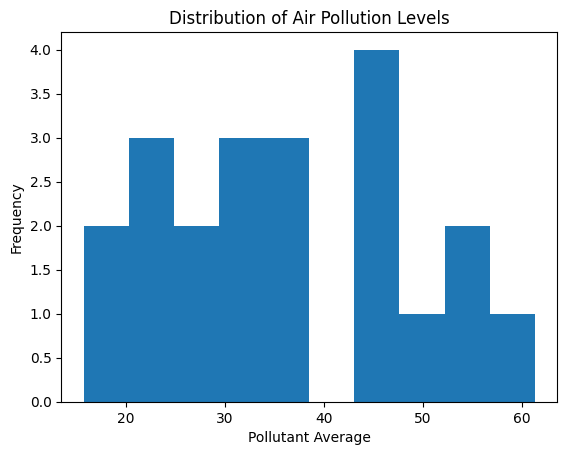

In [ ]:
import matplotlib.pyplot as plt

plt.hist(merged_df['pollutant_avg'], bins=10)
plt.title("Distribution of Air Pollution Levels")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")
plt.show()

2. Top Polluted States

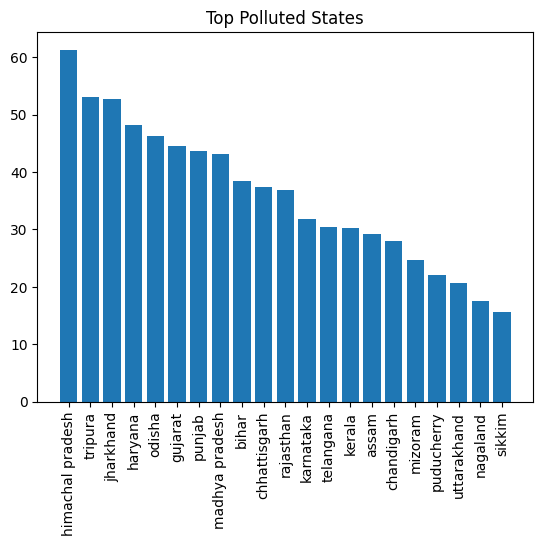

In [ ]:
top_states = merged_df.sort_values(by='pollutant_avg', ascending=False)

plt.bar(top_states['state'], top_states['pollutant_avg'])
plt.xticks(rotation=90)
plt.title("Top Polluted States")
plt.show()

## Health v/s Pollution

1. Tobacco vs Pollution

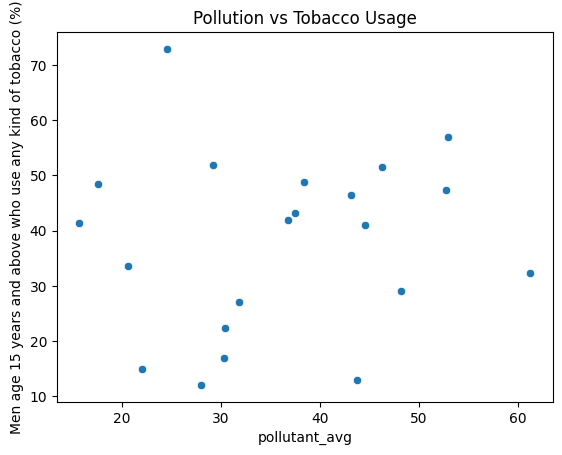

In [ ]:
import seaborn as sns

sns.scatterplot(
    data=merged_df,
    x='pollutant_avg',
    y='Men age 15 years and above who use any kind of tobacco (%)'
)
plt.title("Pollution vs Tobacco Usage")
plt.show()

2. Alcohol vs Pollution

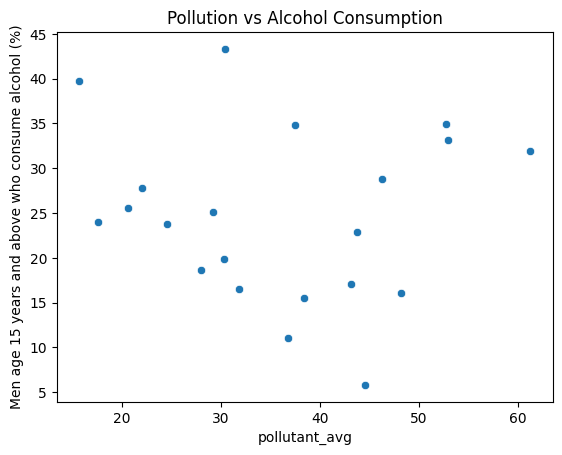

In [ ]:
sns.scatterplot(
    data=merged_df,
    x='pollutant_avg',
    y='Men age 15 years and above who consume alcohol (%)'
)
plt.title("Pollution vs Alcohol Consumption")
plt.show()

## CORRELATION MATRIX

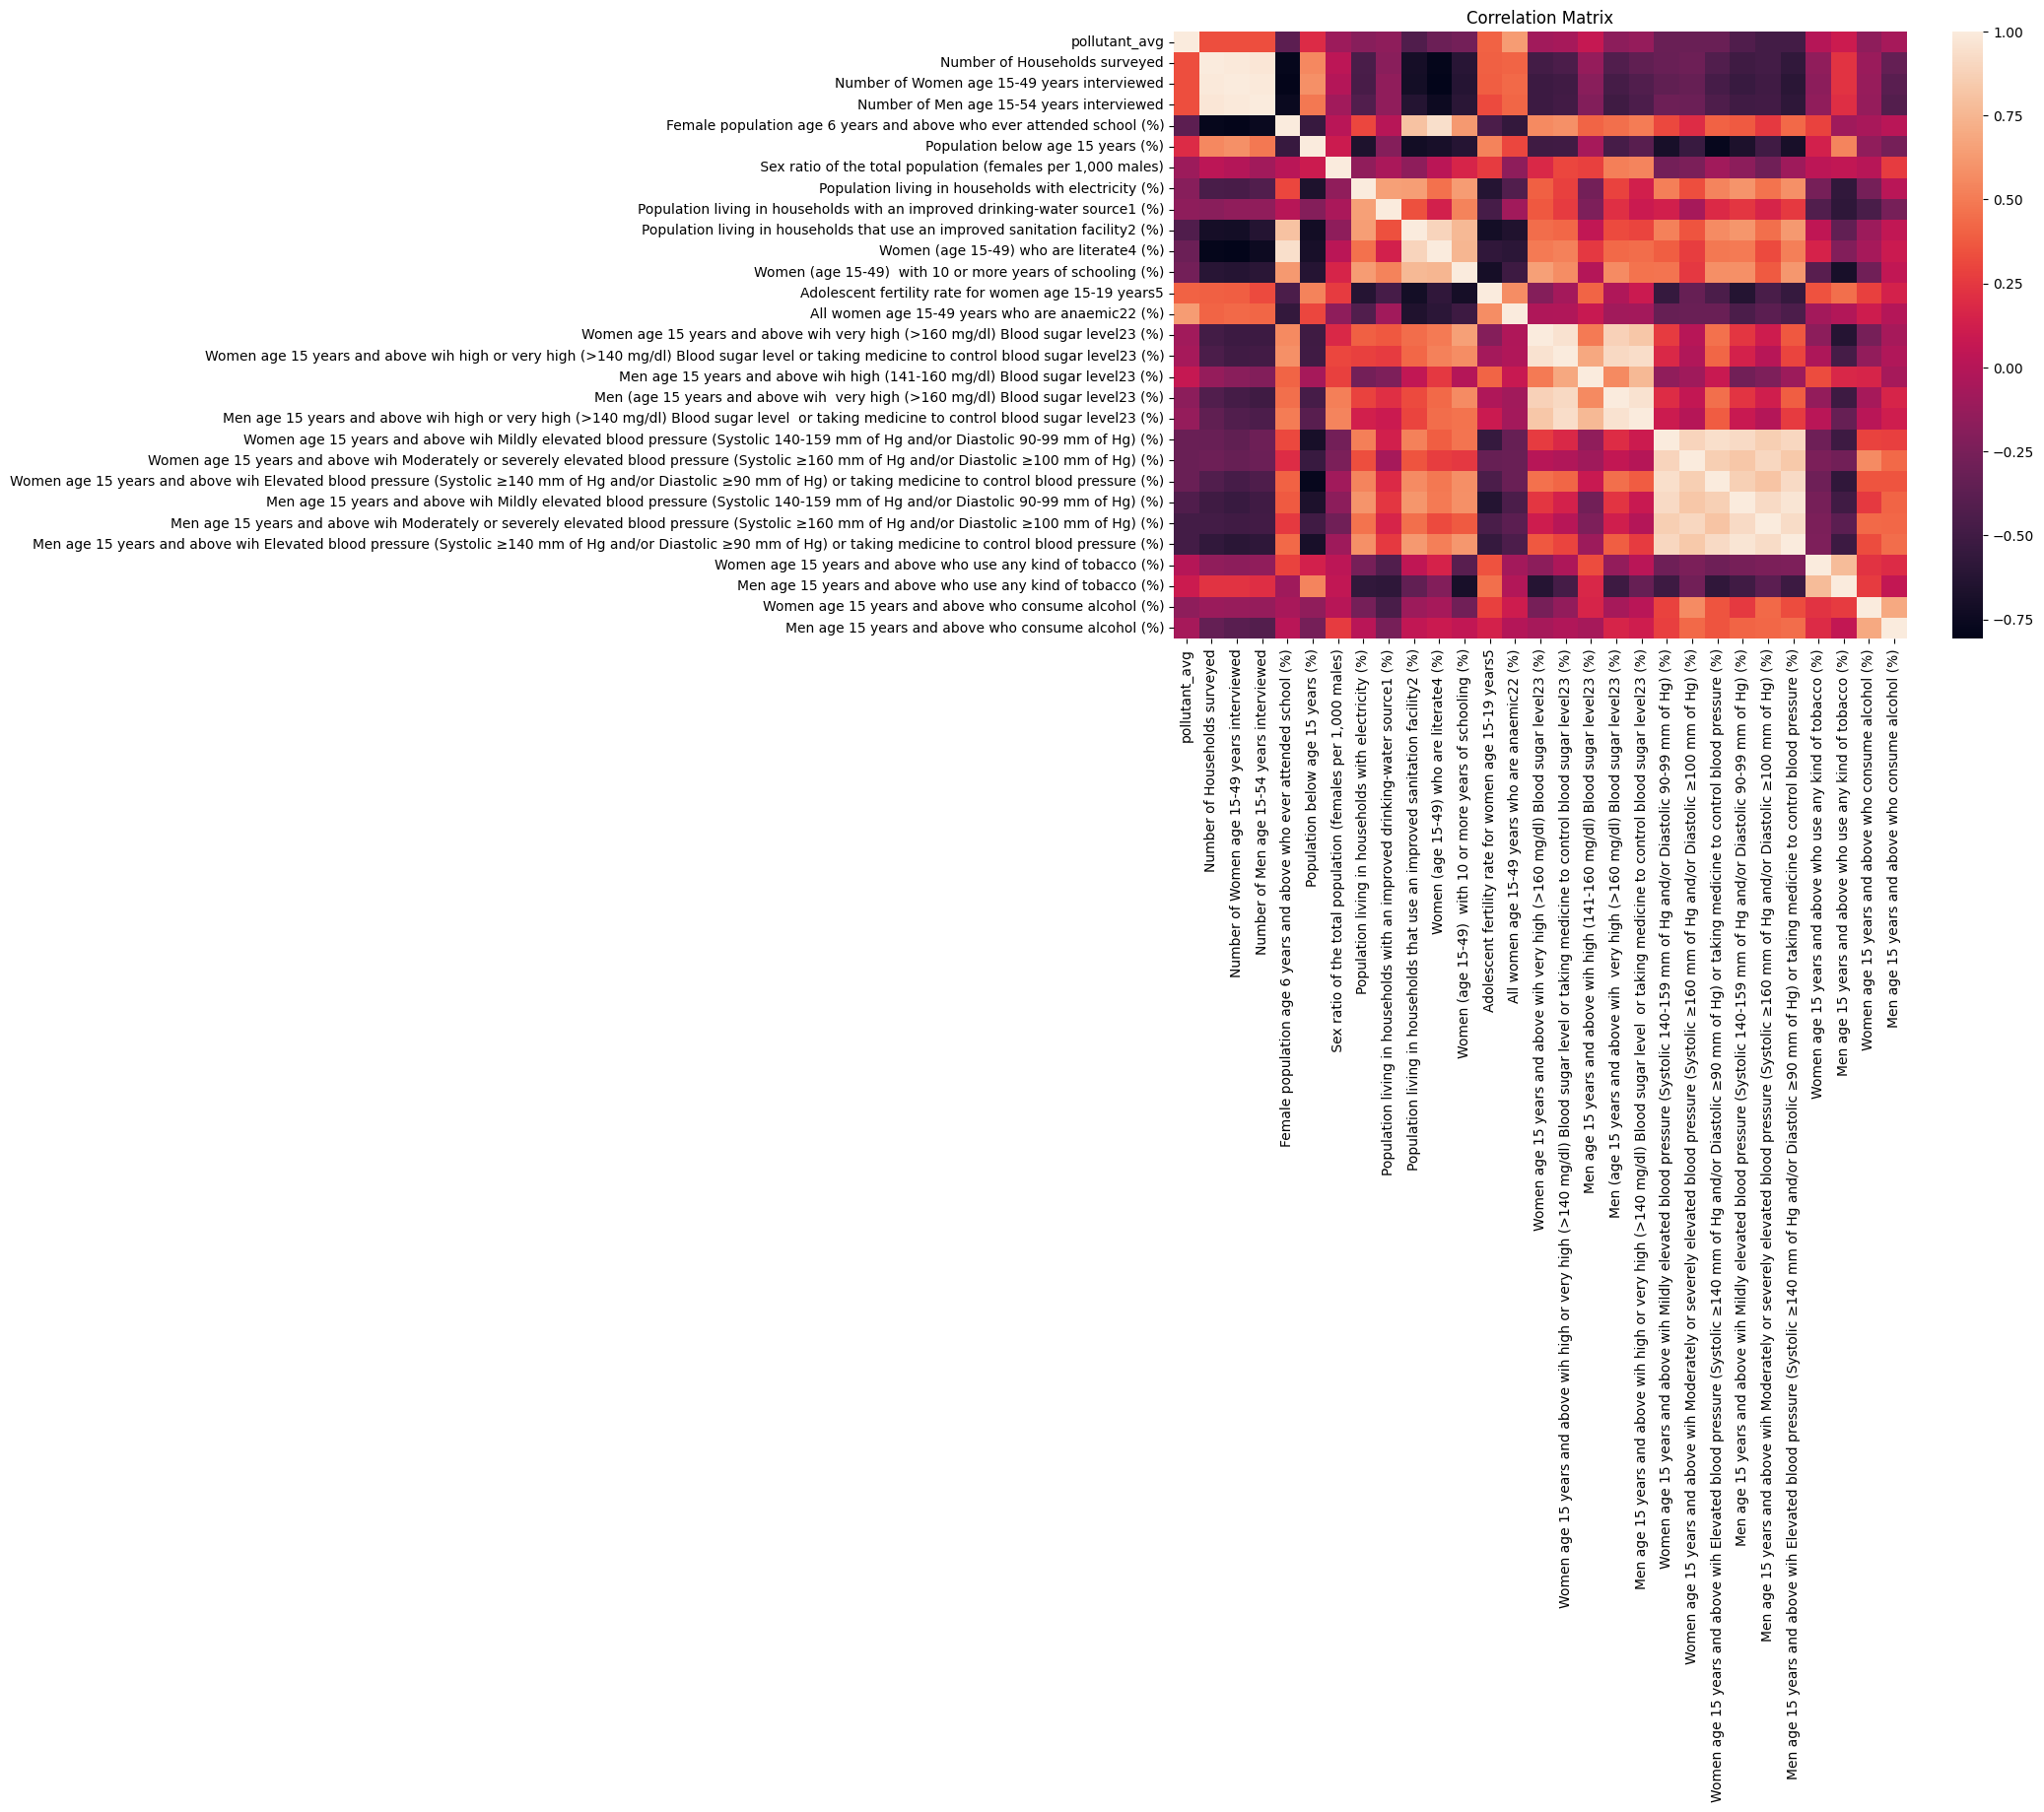

In [ ]:
# Select only numeric columns
numeric_df = merged_df.select_dtypes(include=['float64', 'int64'])

# Correlation
corr = numeric_df.corr()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Remove less useful columns
numeric_df = numeric_df.drop(columns=[
    'Number of Households surveyed'
], errors='ignore')

The study found that air pollution is strongly tied to factors like education, sanitation and infrastructure. These are all important for a countrys development.

When looking at the whole country the link between air pollution and health problems is not very clear.

This means we need more detailed information over a long period to see how being exposed to dirty air really affects peoples health.

We have to consider air pollution, education, sanitation and infrastructure to understand the issue fully.

The connection, between air pollution and health issues is complex. Needs more air pollution data to understand its impact.

## MACHINE LEARNING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (X)
X = numeric_df.drop(columns=['pollutant_avg'])

# Target (y)
y = numeric_df['pollutant_avg']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Score
print("Model Score:", model.score(X_test, y_test))

Model Score: -4.7199397329328105


In [ ]:
selected_features = [
    'Female population age 6 years and above who ever attended school (%)',
    'Population living in households with electricity (%)',
    'Population living in households that use an improved sanitation facility2 (%)',
    'Women (age 15-49 years) who are literate (%)',
    'Women (age 15-49 years) with 10 or more years of schooling (%)',
    'Men age 15 years and above who use any kind of tobacco (%)'
]

In [ ]:
for col in numeric_df.columns:
    print(col)

pollutant_avg
Number of Women age 15-49 years interviewed
Number of Men age 15-54 years interviewed
Female population age 6 years and above who ever attended school (%)
Population below age 15 years (%)
 Sex ratio of the total population (females per 1,000 males)
Population living in households with electricity (%)
Population living in households with an improved drinking-water source1 (%)
Population living in households that use an improved sanitation facility2 (%)
Women (age 15-49) who are literate4 (%)
Women (age 15-49)  with 10 or more years of schooling (%)
Adolescent fertility rate for women age 15-19 years5
All women age 15-49 years who are anaemic22 (%)
Women age 15 years and above wih very high (>160 mg/dl) Blood sugar level23 (%)
Women age 15 years and above wih high or very high (>140 mg/dl) Blood sugar level or taking medicine to control blood sugar level23 (%)
Men age 15 years and above wih high (141-160 mg/dl) Blood sugar level23 (%)
Men (age 15 years and above wih  very 

In [ ]:
selected_features = [
    'Female population age 6 years and above who ever attended school (%)',
    'Population living in households with electricity (%)',
    'Population living in households that use an improved sanitation facility2 (%)',
    'Women (age 15-49) who are literate4 (%)',
    'Women (age 15-49)  with 10 or more years of schooling (%)',
    'Men age 15 years and above who use any kind of tobacco (%)'
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = numeric_df[selected_features]
y = numeric_df['pollutant_avg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Final Model Score:", model.score(X_test, y_test))

Final Model Score: -2.35613421567188


In [ ]:
selected_features = [
    'pollutant_avg',  # keep target temporarily for correlation filtering

    'Female population age 6 years and above who ever attended school (%)',
    'Population living in households with electricity (%)',
    'Population living in households that use an improved sanitation facility2 (%)',

    'Women (age 15-49) who are literate4 (%)',
    'Women (age 15-49)  with 10 or more years of schooling (%)',

    'Men age 15 years and above who use any kind of tobacco (%)',
    'Men age 15 years and above who consume alcohol (%)',

    'Population below age 15 years (%)'
]

In [ ]:
model_df = merged_df[selected_features].dropna()

In [ ]:
model_df = merged_df[selected_features].dropna()

In [ ]:
X = model_df.drop(columns=['pollutant_avg'])
y = model_df['pollutant_avg']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Score (R²):", model.score(X_test, y_test))

Model Score (R²): -0.5960314207626007


In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

Female population age 6 years and above who ever attended school (%)             0.282718
Women (age 15-49)  with 10 or more years of schooling (%)                        0.184318
Men age 15 years and above who consume alcohol (%)                               0.179177
Population living in households that use an improved sanitation facility2 (%)    0.113114
Population living in households with electricity (%)                             0.072831
Women (age 15-49) who are literate4 (%)                                          0.067381
Population below age 15 years (%)                                                0.054645
Men age 15 years and above who use any kind of tobacco (%)                       0.045817
dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 11.258633642284314
RMSE: 12.007591741199253


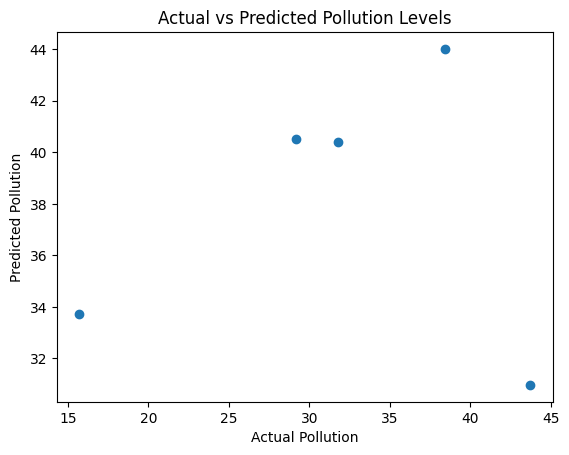

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Actual vs Predicted Pollution Levels")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

coeff = pd.Series(model.coef_, index=X.columns)
coeff = coeff.sort_values(ascending=False)

print(coeff)

Women (age 15-49) who are literate4 (%)                                          20.980562
Men age 15 years and above who consume alcohol (%)                               -0.988887
Men age 15 years and above who use any kind of tobacco (%)                       -1.152753
Population below age 15 years (%)                                                -4.217915
Women (age 15-49)  with 10 or more years of schooling (%)                        -4.279201
Population living in households with electricity (%)                             -6.423017
Population living in households that use an improved sanitation facility2 (%)    -9.979523
Female population age 6 years and above who ever attended school (%)            -12.944221
dtype: float64


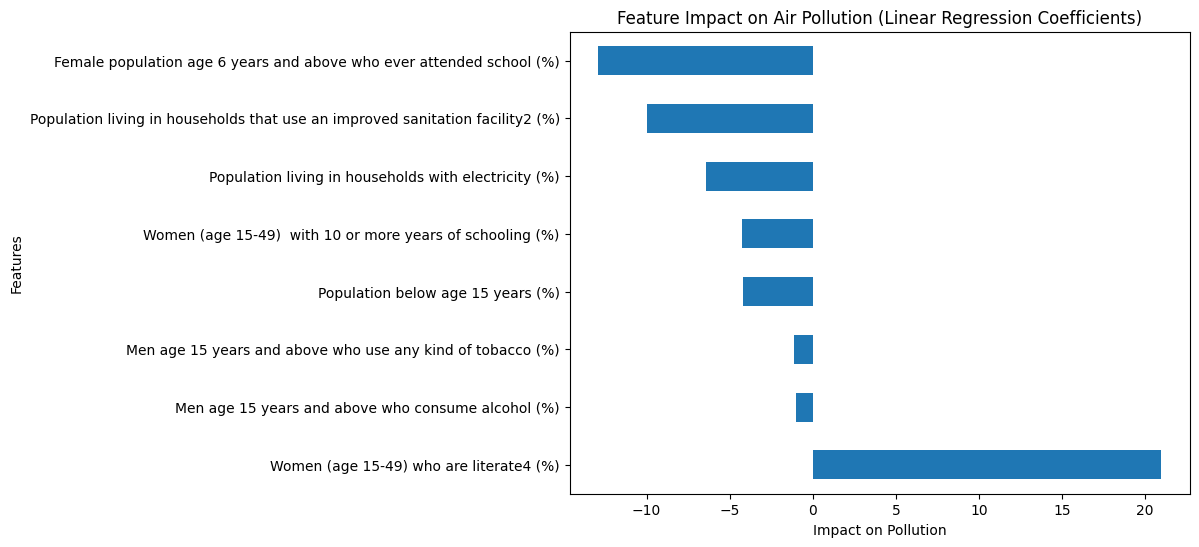

In [ ]:
import matplotlib.pyplot as plt

coeff.plot(kind='barh', figsize=(8,6))
plt.title("Feature Impact on Air Pollution (Linear Regression Coefficients)")
plt.xlabel("Impact on Pollution")
plt.ylabel("Features")
plt.show()

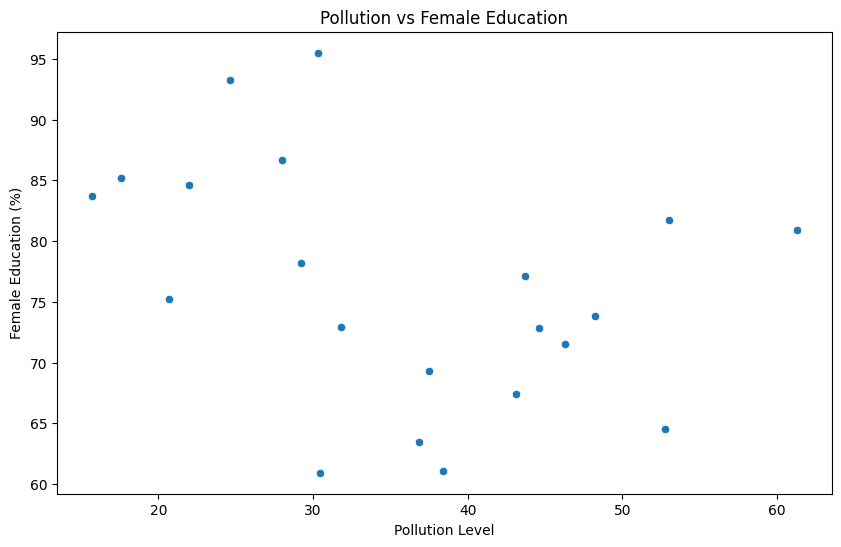

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(x=merged_df['pollutant_avg'],
                y=merged_df['Female population age 6 years and above who ever attended school (%)'])

plt.title("Pollution vs Female Education")
plt.xlabel("Pollution Level")
plt.ylabel("Female Education (%)")
plt.show()